<a href="https://colab.research.google.com/github/sesha-gopalan/Diabetic-Retinopathy-Detection-Using-Deep-Learning/blob/main/Diabetic_Retinopathy_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#install Tensorflow
!pip  install tensorflow

In [2]:
#install cv2
!pip install opencv-contrib-python

In [3]:
# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

# 2. Unzip the dataset into the local Colab environment
# Replace 'my_dataset.zip' with your actual zip file name
!unzip -q "/content/drive/MyDrive/DR_Model_Dataset.zip" -d "/content/dataset/"

Mounted at /content/drive


In [4]:
#Segmentation
import os
# Define your base path
base_path = '/content/dataset'

# List all subfolders (e.g., ['train', 'test', 'val'])
folders = os.listdir(base_path)
print("Subfolders found:", folders)

# Example: Loop through files inside the 'train' folder
train_path = os.path.join(base_path, 'train')
for root, dirs, files in os.walk(train_path):
    print(f"Found directory: {root} with {len(files)} files")

Subfolders found: ['Segmentation', 'Disease_Grading', 'Localization']


In [5]:
#finding image directories
import os

disease_grading_path = os.path.join(base_path, 'Disease_Grading')

# List contents of the Disease_Grading folder
if os.path.exists(disease_grading_path):
    print(f"Contents of '{disease_grading_path}':")
    for item in os.listdir(disease_grading_path):
        item_path = os.path.join(disease_grading_path, item)
        if os.path.isdir(item_path):
            print(f"  [DIR] {item} (contains {len(os.listdir(item_path))} items)")
        else:
            print(f"  [FILE] {item}")
else:
    print(f"Error: '{disease_grading_path}' does not exist.")


Contents of '/content/dataset/Disease_Grading':
  [DIR] Groundtruths (contains 2 items)
  [DIR] Original_Images (contains 2 items)


In [6]:
#Create image generator
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Define the base path for original images, using disease_grading_path from previous cells
original_images_base_path = os.path.join(disease_grading_path, 'Original_Images')

# Define paths for training and testing images
train_images_path = os.path.join(original_images_base_path, 'Training Set')
test_images_path = os.path.join(original_images_base_path, 'Testing Set')

print(f"Image dimensions set to: {IMG_HEIGHT}x{IMG_WIDTH}, Batch size: {BATCH_SIZE}")
print(f"Training images will be loaded from: {train_images_path}")
print(f"Testing images will be loaded from: {test_images_path}")

# --- Create ImageDataGenerators ---
# For training, include augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# For validation/testing, only rescale (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

print("ImageDataGenerators initialized.")

Image dimensions set to: 224x224, Batch size: 32
Training images will be loaded from: /content/dataset/Disease_Grading/Original_Images/Training Set
Testing images will be loaded from: /content/dataset/Disease_Grading/Original_Images/Testing Set
ImageDataGenerators initialized.


In [7]:
#find and connect csv files
import os

groundtruths_path = os.path.join(disease_grading_path, 'Groundtruths')

print(f"Contents of '{groundtruths_path}':")
if os.path.exists(groundtruths_path):
    for item in os.listdir(groundtruths_path):
        item_path = os.path.join(groundtruths_path, item)
        if os.path.isdir(item_path):
            print(f"  [DIR] {item} (contains {len(os.listdir(item_path))} items)")
        else:
            print(f"  [FILE] {item}")
else:
    print(f"Error: '{groundtruths_path}' does not exist.")


Contents of '/content/dataset/Disease_Grading/Groundtruths':
  [FILE] IDRiD_Disease Grading_Testing Labels.csv
  [FILE] IDRiD_Disease Grading_Training Labels.csv


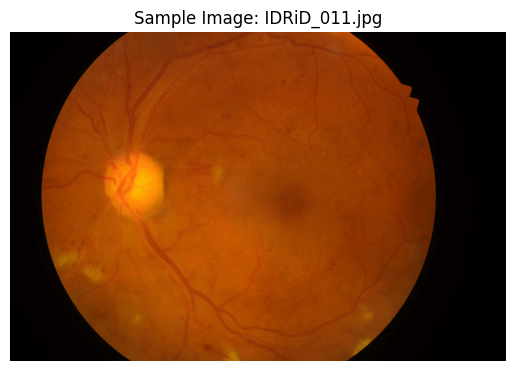

In [8]:
#generate sample image
import matplotlib.pyplot as plt
from PIL import Image
import os

# Path to the Original_Images within Disease_Grading
original_images_path = os.path.join(disease_grading_path, 'Original_Images', 'Training Set')

# Get a list of image files
image_files = [f for f in os.listdir(original_images_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

if image_files:
    # Select a sample image (e.g., the first one)
    sample_image_name = image_files[0]
    sample_image_path = os.path.join(original_images_path, sample_image_name)

    # Load and display the image
    img = Image.open(sample_image_path)
    plt.imshow(img)
    plt.title(f'Sample Image: {sample_image_name}')
    plt.axis('off') # Hide axes ticks
    plt.show()
else:
    print(f"No image files found in '{original_images_path}'")


In [9]:
#display tables in csv file
import pandas as pd

training_labels_path = os.path.join(groundtruths_path, 'IDRiD_Disease Grading_Training Labels.csv')

# Load the training labels CSV file
train_labels_df = pd.read_csv(training_labels_path)

# Display the first few rows of the DataFrame
display(train_labels_df.head())

# Also print some info to check data types and non-null counts
print(train_labels_df.info())


,Image name,Retinopathy grade,Risk of macular edema,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,IDRiD_001,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IDRiD_002,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IDRiD_003,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IDRiD_004,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IDRiD_005,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 413 entries, 0 to 412
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Image name              413 non-null    object 
 1   Retinopathy grade       413 non-null    int64  
 2   Risk of macular edema   413 non-null    int64  
 3   Unnamed: 3              0 non-null      float64
 4   Unnamed: 4              0 non-null      float64
 5   Unnamed: 5              0 non-null      float64
 6   Unnamed: 6              0 non-null      float64
 7   Unnamed: 7              0 non-null      float64
 8   Unnamed: 8              0 non-null      float64
 9   Unnamed: 9              0 non-null      float64
 10  Unnamed: 10             0 non-null      float64
 11  Unnamed: 11             1 non-null      object 
dtypes: float64(8), int64(2), object(2)
memory usage: 38.8+ KB
None


In [10]:
#drop un/wanted columns
columns_to_drop = [col for col in train_labels_df.columns if 'Unnamed:' in col]
train_labels_df_cleaned = train_labels_df.drop(columns=columns_to_drop)
display(train_labels_df_cleaned.head())

,Image name,Retinopathy grade,Risk of macular edema
0,IDRiD_001,3,2
1,IDRiD_002,3,2
2,IDRiD_003,2,2
3,IDRiD_004,3,2
4,IDRiD_005,4,0


In [11]:
#examine the testing csv file
testing_labels_path = os.path.join(groundtruths_path, 'IDRiD_Disease Grading_Testing Labels.csv')

# Load the testing labels CSV file
test_labels_df = pd.read_csv(testing_labels_path)

# Determine which 'Unnamed' columns actually exist in the test DataFrame and drop them
# This handles cases where the test CSV might have some, all, or none of the 'Unnamed' columns
existing_unnamed_cols = [col for col in test_labels_df.columns if 'Unnamed:' in col]

if existing_unnamed_cols:
    test_labels_df_cleaned = test_labels_df.drop(columns=existing_unnamed_cols)
else:
    # If no 'Unnamed' columns are found, the DataFrame is already clean
    test_labels_df_cleaned = test_labels_df.copy()

# Display the first few rows of the cleaned testing DataFrame
display(test_labels_df_cleaned.head())

print(test_labels_df_cleaned.info())

,Image name,Retinopathy grade,Risk of macular edema
0,IDRiD_001,4,0
1,IDRiD_002,4,1
2,IDRiD_003,4,0
3,IDRiD_004,4,0
4,IDRiD_005,4,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Image name              103 non-null    object
 1   Retinopathy grade       103 non-null    int64 
 2   Risk of macular edema   103 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 2.5+ KB
None


In [12]:
#Details on what folder contains what kind of images
import os

# Path to the Original_Images within Disease_Grading
original_images_base_path = os.path.join(disease_grading_path, 'Original_Images')

print(f"Contents of '{original_images_base_path}':")
if os.path.exists(original_images_base_path):
    for item in os.listdir(original_images_base_path):
        item_path = os.path.join(original_images_base_path, item)
        if os.path.isdir(item_path):
            print(f"  [DIR] {item} (contains {len(os.listdir(item_path))} items)")
        else:
            print(f"  [FILE] {item}")
else:
    print(f"Error: '{original_images_base_path}' does not exist.")


Contents of '/content/dataset/Disease_Grading/Original_Images':
  [DIR] Testing Set (contains 103 items)
  [DIR] Training Set (contains 413 items)


In [13]:
# Ensure 'Image name' column is string type and add '.jpg' extension if not present
train_labels_df_cleaned['Image name'] = train_labels_df_cleaned['Image name'].astype(str)
train_labels_df_cleaned['Image name'] = train_labels_df_cleaned['Image name'].apply(lambda x: x + '.jpg' if not x.endswith('.jpg') else x)

test_labels_df_cleaned['Image name'] = test_labels_df_cleaned['Image name'].astype(str)
test_labels_df_cleaned['Image name'] = test_labels_df_cleaned['Image name'].apply(lambda x: x + '.jpg' if not x.endswith('.jpg') else x)

# Convert 'Retinopathy grade' to string for flow_from_dataframe, as it expects string labels for 'categorical' class_mode
train_labels_df_cleaned['Retinopathy grade'] = train_labels_df_cleaned['Retinopathy grade'].astype(str)
test_labels_df_cleaned['Retinopathy grade'] = test_labels_df_cleaned['Retinopathy grade'].astype(str)

# Create data generators
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_labels_df_cleaned,
    directory=train_images_path,
    x_col='Image name',
    y_col='Retinopathy grade',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical', # Use 'categorical' for multiclass classification
    shuffle=True,
    seed=42
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_labels_df_cleaned,
    directory=test_images_path,
    x_col='Image name',
    y_col='Retinopathy grade',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False, # Do not shuffle test data
    seed=42
)

print("Train and test data generators created successfully.")

Found 413 validated image filenames belonging to 5 classes.
Found 103 validated image filenames belonging to 5 classes.
Train and test data generators created successfully.


In [14]:
#compile model
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import AUC
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Define the number of classes based on your data (Retinopathy grades 0-4 = 5 classes)
num_classes = len(train_generator.class_indices)

# Load pre-trained MobileNetV2 model
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), include_top=False, weights='imagenet')

# Freeze the base model layers to prevent retraining during the initial phase
base_model.trainable = False

# Add a classification head on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x) # Additional dense layer
predictions = Dense(num_classes, activation='softmax')(x) # Output layer for 5 classes

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001), # Using a small learning rate for fine-tuning
    loss=CategoricalCrossentropy(),
    metrics=['accuracy', AUC(name='auc')]
)

print("Model compiled successfully.")
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Model compiled successfully.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
#train model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define callbacks
checkpoint_filepath = 'best_model.h5'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False, # Save the entire model
    monitor='val_accuracy', # Monitor validation accuracy
    mode='max', # We want to maximize validation accuracy
    save_best_only=True
)

early_stopping_callback = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=10, # Stop if validation loss doesn't improve for 10 epochs
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity.
)

# Train the model
history = model.fit(
    train_generator,
    epochs=5, # Set a reasonable number of epochs; EarlyStopping will prevent overfitting
    validation_data=test_generator,
    callbacks=[model_checkpoint_callback, early_stopping_callback]
)

print("Model training completed.")

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2224 - auc: 0.5055 - loss: 2.0202

13/13 ━━━━━━━━━━━━━━━━━━━━ 93s 6s/step - accuracy: 0.2615 - auc: 0.5884 - loss: 1.7712 - val_accuracy: 0.3204 - val_auc: 0.6977 - val_loss: 1.5095
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3565 - auc: 0.7053 - loss: 1.4645

13/13 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.3753 - auc: 0.7089 - loss: 1.4600 - val_accuracy: 0.4272 - val_auc: 0.7437 - val_loss: 1.3818
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4329 - auc: 0.7566 - loss: 1.3376

13/13 ━━━━━━━━━━━━━━━━━━━━ 39s 3s/step - accuracy: 0.4262 - auc: 0.7603 - loss: 1.3375 - val_accuracy: 0.4466 - val_auc: 0.7587 - val_loss: 1.3494
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4425 - auc: 0.7910 - loss: 1.2522

13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.4310 - auc: 0.7807 - loss: 1.2817 - val_accuracy: 0.4757 - val_auc: 0.7802 - val_loss: 1.2829
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4695 - auc: 0.8061 - loss: 1.2160

13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.4600 - auc: 0.7936 - loss: 1.2459 - val_accuracy: 0.5049 - val_auc: 0.7933 - val_loss: 1.2484
Model training completed.


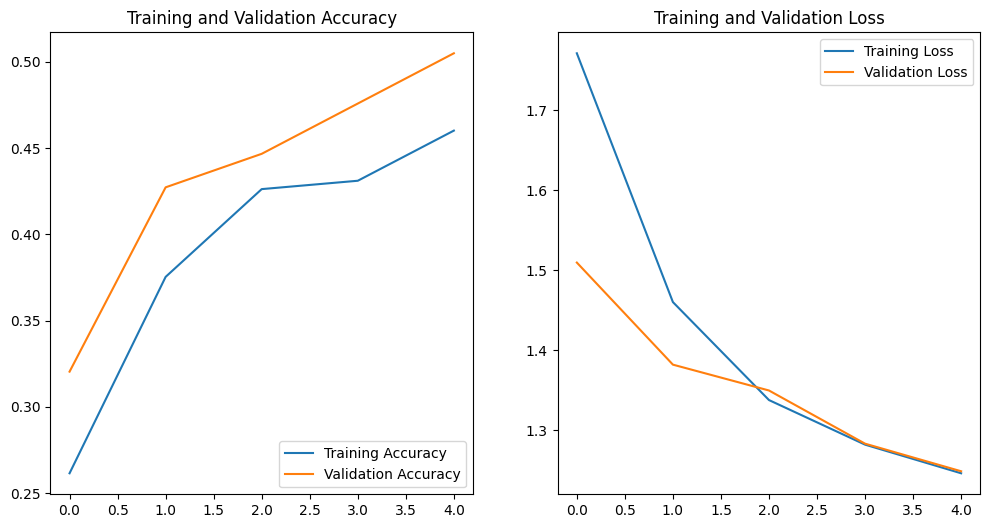

In [16]:
#Plotting training loss and efficiency
import matplotlib.pyplot as plt

# Get training history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [17]:
#define image processing function
import numpy as np
from PIL import Image
import io

def preprocess_uploaded_image(image_bytes):
    """Preprocesses an uploaded image for model prediction."""
    img = Image.open(io.BytesIO(image_bytes))
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))
    img_array = np.array(img)
    # Add batch dimension and normalize (rescale=1./255)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array.astype('float32') / 255.0
    return img_array

print("Image preprocessing function defined.")

Image preprocessing function defined.


In [18]:
#Create button and widgets for future prediction cases
from IPython.display import display
from ipywidgets import FileUpload, Button, Output

# Create a file uploader widget
upload_widget = FileUpload(accept='.jpg, .jpeg, .png', multiple=False)
output_widget = Output()
predict_button = Button(description='Predict DR Stage')

print("File upload widget and prediction button created.")

File upload widget and prediction button created.


In [19]:
#Test model using user prediction
import matplotlib.pyplot as plt

def on_predict_button_clicked(b):
    with output_widget:
        output_widget.clear_output()
        if not upload_widget.value:
            print("Please upload an image first.")
            return

        # Get the uploaded file content
        uploaded_file = list(upload_widget.value.values())[0]
        image_bytes = uploaded_file['content']
        original_img = Image.open(io.BytesIO(image_bytes))

        # Preprocess the image
        preprocessed_image = preprocess_uploaded_image(image_bytes)

        # Make prediction
        predictions = model.predict(preprocessed_image)
        predicted_class_index = np.argmax(predictions, axis=1)[0]

        # Get class labels from the generator (if needed, map to more readable names)
        class_labels = list(train_generator.class_indices.keys())
        predicted_dr_stage = class_labels[predicted_class_index]

        # Display the uploaded image and prediction
        plt.figure(figsize=(6, 6))
        plt.imshow(original_img)
        plt.title(f"Predicted DR Stage: {predicted_dr_stage} (Confidence: {predictions[0][predicted_class_index]:.2f})")
        plt.axis('off')
        plt.show()

predict_button.on_click(on_predict_button_clicked)

# Display the widgets
display(upload_widget, predict_button, output_widget)

FileUpload(value={}, accept='.jpg, .jpeg, .png', description='Upload')

Button(description='Predict DR Stage', style=ButtonStyle())

Output()

4/4 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step


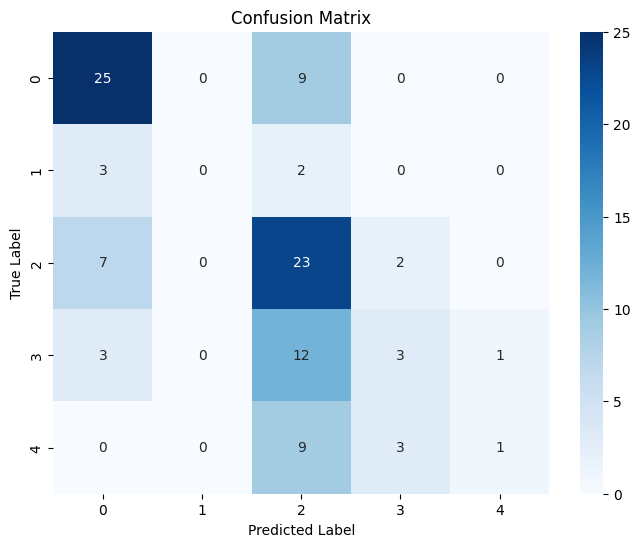


Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.74      0.69        34
           1       0.00      0.00      0.00         5
           2       0.42      0.72      0.53        32
           3       0.38      0.16      0.22        19
           4       0.50      0.08      0.13        13

    accuracy                           0.50       103
   macro avg       0.39      0.34      0.32       103
weighted avg       0.48      0.50      0.45       103



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
#Create confusion matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Reset the test generator to ensure predictions are made from the start
test_generator.reset()

# Get predictions from the model on the test set
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

# Get true labels from the test generator
true_classes = test_generator.classes

# Get class labels from the generator
class_labels = list(test_generator.class_indices.keys())

# Compute the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Print classification report for more detailed metrics
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

In [21]:
#Grad cam function definition
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Create a model that maps the input image to the activations of the last convolutional layer as well as the output predictions
    grad_model = Model(
        inputs=model.inputs, outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute the gradient of the top predicted class for our input image
    # with respect to the activations of the last convolutional layer
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # This is the gradient of the output neuron (top predicted or chosen) with respect to the output feature map of the last conv layer
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # This is a vector where each entry is the mean intensity of the gradient over a specific feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map array by "how important this channel is" with regard to the top predicted class
    # then sum all the channels to obtain the heatmap class activation
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # For visualization purpose, normalize the heatmap between 0 & 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4):
    # Load the original image
    img = cv2.imread(img_path)
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))

    # Rescale heatmap to a range 0-255
    heatmap = np.uint8(255 * heatmap)

    # Use jet colormap to colorize heatmap
    jet = plt.cm.get_cmap("jet")

    # Use RGB values of the colormap
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]

    # Create an image with RGB colorized heatmap
    jet_heatmap = image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = image.img_to_array(jet_heatmap)

    # Superimpose the heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = image.array_to_img(superimposed_img)

    # Display Image
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.show()

print("Grad-CAM helper functions defined.")

Grad-CAM helper functions defined.


Using last convolutional layer: Conv_1_bn


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


/tmp/ipykernel_816/2368942602.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


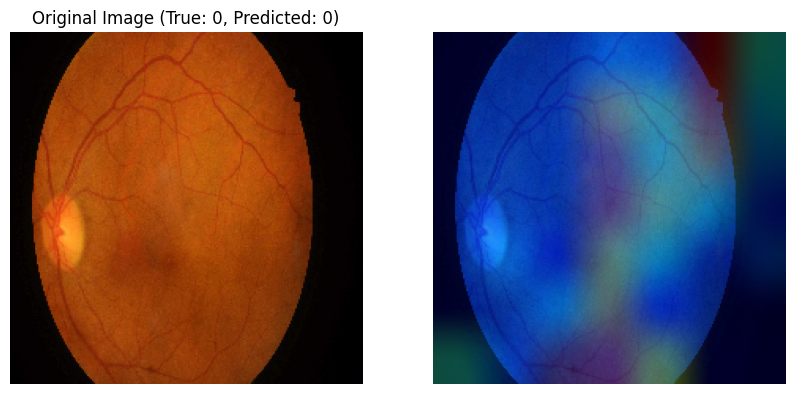

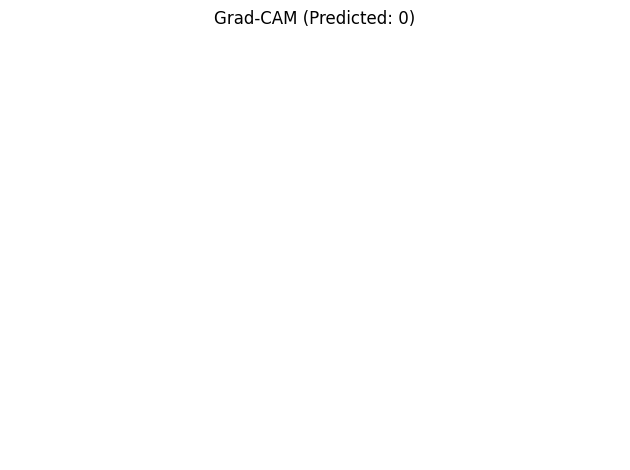

In [22]:
#Grad cam visualization
import random
import os

# Get a random image from the test set for Grad-CAM demonstration
# Ensure test_images_path and test_labels_df_cleaned are defined from previous cells

# List all image files in the testing set directory
all_test_images = os.listdir(test_images_path)

# Filter for actual image files (e.g., .jpg)
image_filenames = [f for f in all_test_images if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if image_filenames:
    # Select a random image
    random_image_name = random.choice(image_filenames)
    random_image_path = os.path.join(test_images_path, random_image_name)

    # Find its true label
    true_label_df = test_labels_df_cleaned[test_labels_df_cleaned['Image name'] == random_image_name]
    true_label = true_label_df['Retinopathy grade'].iloc[0] if not true_label_df.empty else 'Unknown'

    # Preprocess the image for the model
    img = image.load_img(random_image_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array.astype('float32') / 255.0 # Normalize similar to ImageDataGenerator

    # Get the name of the last convolutional layer. This might vary based on the exact MobileNetV2 architecture.
    # A common way is to inspect model.summary() or know the architecture.
    # For MobileNetV2, a good candidate is often 'Conv_1'. Let's try to find it dynamically.
    last_conv_layer_name = None
    for layer in reversed(model.layers):
        if len(layer.get_weights()) > 0 and 'conv' in layer.name.lower():
            last_conv_layer_name = layer.name
            break

    if last_conv_layer_name is None:
        print("Could not find a convolutional layer. Please check your model architecture.")
    else:
        print(f"Using last convolutional layer: {last_conv_layer_name}")

        # Generate Grad-CAM heatmap
        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

        # Predict class to display in title
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions[0])
        predicted_class_label = class_labels[predicted_class_index]

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Original Image (True: {true_label}, Predicted: {predicted_class_label})")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        display_gradcam(random_image_path, heatmap)
        plt.title(f"Grad-CAM (Predicted: {predicted_class_label})")
        plt.axis('off')

        plt.tight_layout()
        plt.show()

else:
    print(f"No image files found in '{test_images_path}' for Grad-CAM demonstration.")

In [23]:
#test the model
print("Evaluating model on the test set...")
loss, accuracy, auc = model.evaluate(test_generator)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test AUC: {auc:.4f}")

Evaluating model on the test set...
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5049 - auc: 0.7933 - loss: 1.2484
Test Loss: 1.2484
Test Accuracy: 0.5049
Test AUC: 0.7933
